# 잠재 공간 기반 유사성 판단

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_distances

## 데이터 불러오기

In [ ]:
# MNIST 손글씨 데이터
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 488kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.87MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.9MB/s]


## 오토인코더 모델 정의

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # 28x28 → 14x14
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # 14x14 → 7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32*7*7, latent_dim)  # Latent vector
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32*7*7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, output_padding=1, padding=1),
            nn.Sigmoid()  # 픽셀 값은 0~1
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

## 학습 함수

In [ ]:
def train(model, loader, optimizer, criterion, device, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x, _ in loader:
            x = x.to(device)
            optimizer.zero_grad()
            x_hat = model(x)
            loss = criterion(x_hat, x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(loader):.4f}")

## 학습 & 잠재 벡터 추출

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoEncoder(latent_dim=16).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

train(model, train_loader, optimizer, criterion, device)

Epoch 1, Loss: 0.0481
Epoch 2, Loss: 0.0181
Epoch 3, Loss: 0.0152
Epoch 4, Loss: 0.0137
Epoch 5, Loss: 0.0127
Epoch 6, Loss: 0.0120
Epoch 7, Loss: 0.0115
Epoch 8, Loss: 0.0111
Epoch 9, Loss: 0.0108
Epoch 10, Loss: 0.0105


## 테스트셋에서 잠재 벡터 추출

In [ ]:
model.eval()
latents = []
images = []
labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        z = model.encoder(x)
        latents.append(z.cpu())
        images.append(x.cpu())
        labels.extend(y.numpy())

latents = torch.cat(latents).numpy()
images = torch.cat(images).numpy()
labels = np.array(labels)

## 잠재 벡터 거리 기반 유사 이미지 찾기

In [ ]:
def show_similar_images(index, topk=5):
    base = latents[index].reshape(1, -1)
    distances = cosine_distances(base, latents)[0]
    nearest = np.argsort(distances)[1:topk+1]  # 자기 자신 제외

    plt.figure(figsize=(10, 2))
    plt.subplot(1, topk+1, 1)
    plt.imshow(images[index][0], cmap='gray')
    plt.title(f"Query\nLabel: {labels[index]}")
    plt.axis('off')

    for i, idx in enumerate(nearest):
        plt.subplot(1, topk+1, i+2)
        plt.imshow(images[idx][0], cmap='gray')
        plt.title(f"{labels[idx]}")
        plt.axis('off')
    plt.suptitle("Top-k Similar Images (Latent Space)", fontsize=14)
    plt.show()

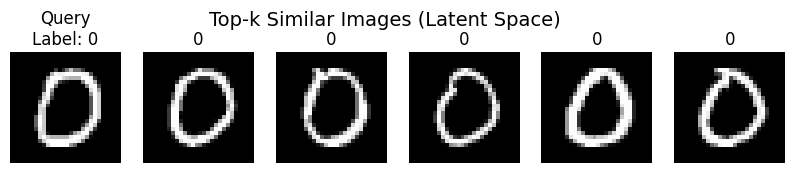

In [ ]:
show_similar_images(index=10, topk=5)

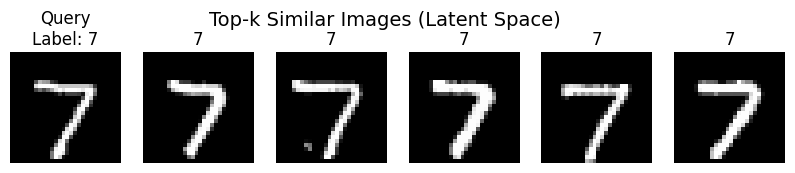

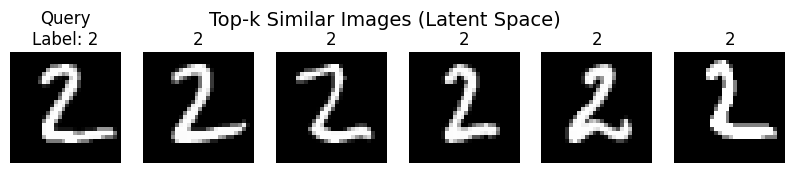

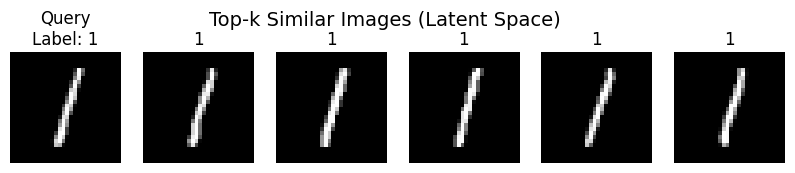

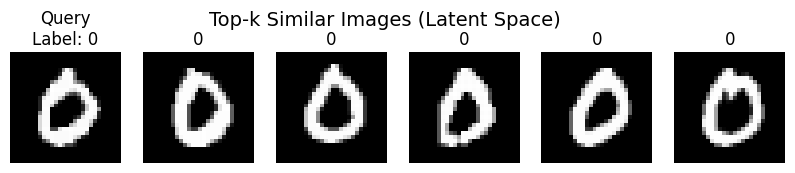

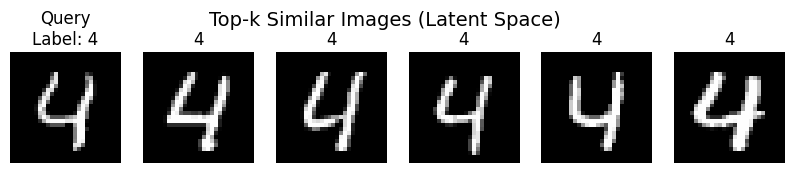

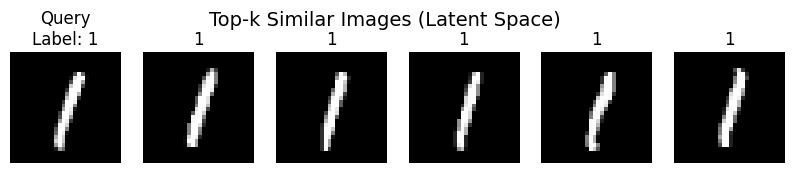

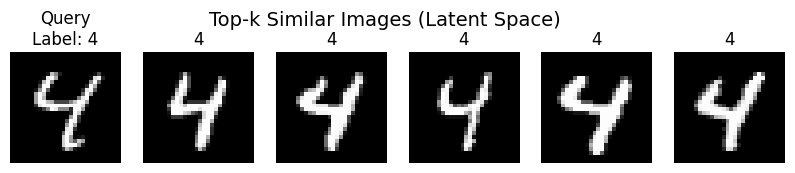

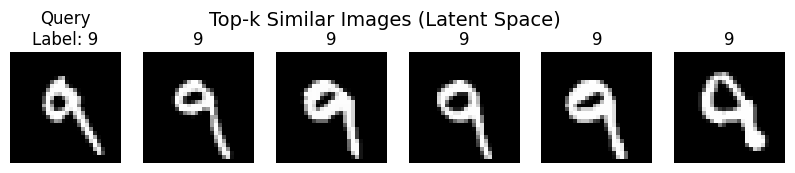

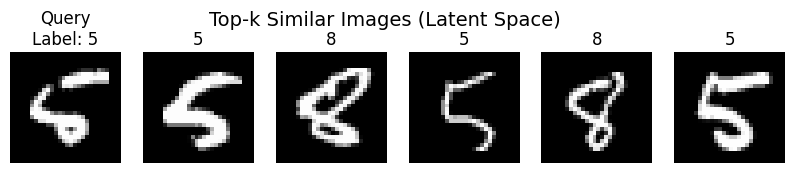

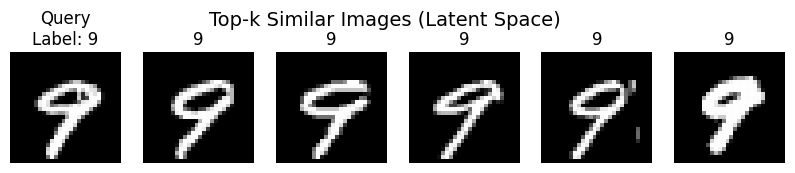

In [ ]:
for i in range(10):
    show_similar_images(index=i, topk=5)

## 잠재 공간 시각화

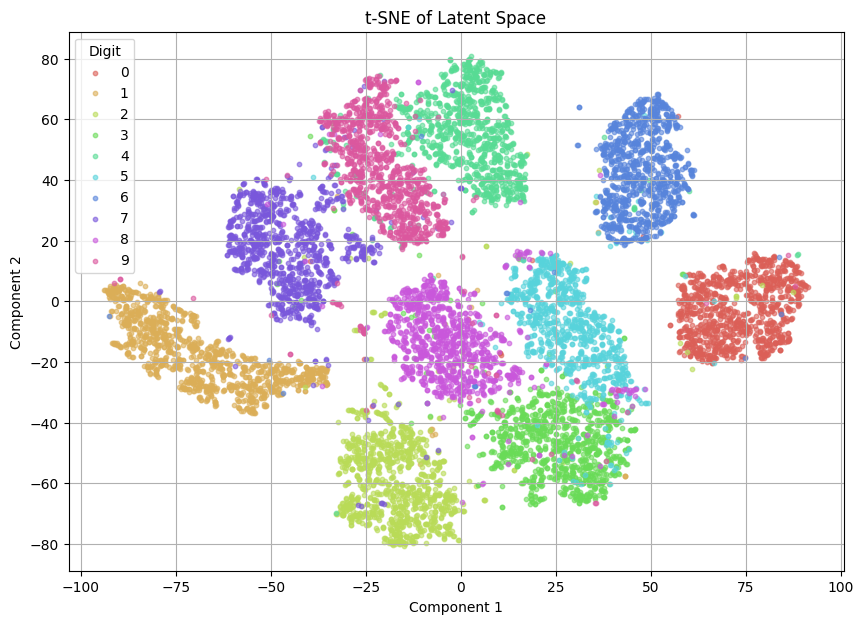

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# 16차원 → 2차원 축소
tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(latents)

# 시각화
plt.figure(figsize=(10, 7))
palette = sns.color_palette("hls", 10)

for i in range(10):
    idx = labels == i
    plt.scatter(z_2d[idx, 0], z_2d[idx, 1], label=str(i), s=10, alpha=0.6, color=palette[i])

plt.legend(title="Digit")
plt.title("t-SNE of Latent Space")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()


## 전체 샘플에 대해 반복

In [ ]:
from sklearn.metrics.pairwise import cosine_distances
import numpy as np

def precision_at_k(latents, labels, k=5):
    num_samples = len(latents)
    correct = []

    # 전체 샘플에 대해 반복
    for i in range(num_samples):
        base = latents[i].reshape(1, -1)
        distances = cosine_distances(base, latents)[0]
        ranked = np.argsort(distances)[1:k+1]  # 자기 자신 제외

        # Top-k 중 레이블이 같은 것의 개수
        true_label = labels[i]
        match_count = np.sum(labels[ranked] == true_label)
        precision = match_count / k
        correct.append(precision)

    return np.mean(correct)

In [ ]:
p_at_5 = precision_at_k(latents, labels, k=5)
p_at_10 = precision_at_k(latents, labels, k=10)

print(f"Precision@5: {p_at_5:.4f}")
print(f"Precision@10: {p_at_10:.4f}")

Precision@5: 0.9427
Precision@10: 0.9306


# MNIST Fashion 데이터

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.92MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


Epoch 1, Loss: 0.0429
Epoch 2, Loss: 0.0176
Epoch 3, Loss: 0.0156
Epoch 4, Loss: 0.0145
Epoch 5, Loss: 0.0138
Epoch 6, Loss: 0.0133
Epoch 7, Loss: 0.0130
Epoch 8, Loss: 0.0127
Epoch 9, Loss: 0.0124
Epoch 10, Loss: 0.0123
Precision@5: 0.7871
Precision@10: 0.7726


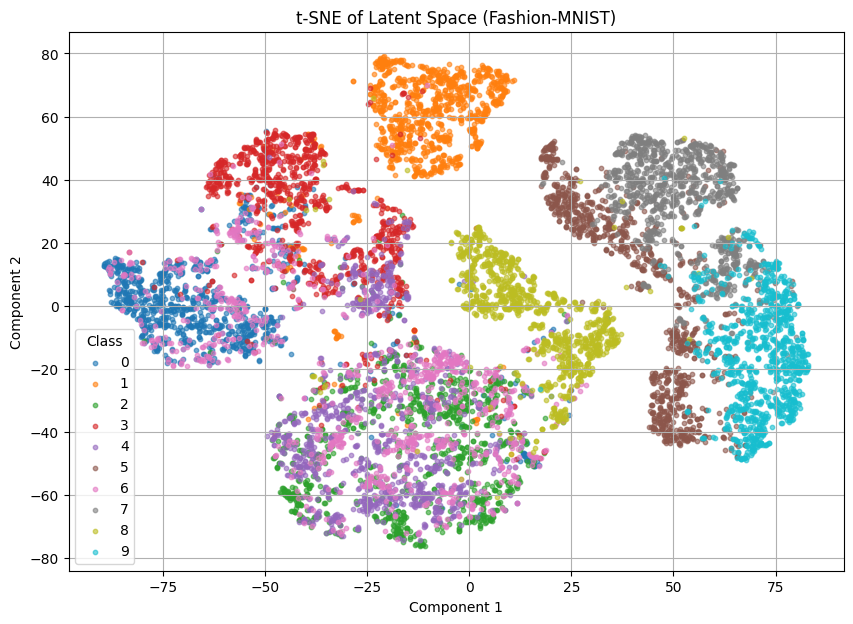

In [ ]:
# 본 설정
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics.pairwise import cosine_distances
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 데이터셋: Fashion-MNIST
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 오토인코더 모델
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 32 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, output_padding=1, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

# 학습 루프
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoEncoder(latent_dim=16).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

def train(model, loader, optimizer, criterion, device, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x, _ in loader:
            x = x.to(device)
            optimizer.zero_grad()
            x_hat = model(x)
            loss = criterion(x_hat, x)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(loader):.4f}")

train(model, train_loader, optimizer, criterion, device)

# 잠재 벡터 추출
latents, images, labels = [], [], []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        z = model.encoder(x)
        latents.append(z.cpu())
        images.append(x.cpu())
        labels.extend(y.numpy())

latents = torch.cat(latents).numpy()
images = torch.cat(images).numpy()
labels = np.array(labels)

# Precision@k 계산 함수
def precision_at_k(latents, labels, k=5):
    correct = []
    for i in range(len(latents)):
        base = latents[i].reshape(1, -1)
        distances = cosine_distances(base, latents)[0]
        ranked = np.argsort(distances)[1:k+1]
        precision = np.sum(labels[ranked] == labels[i]) / k
        correct.append(precision)
    return np.mean(correct)

# Precision@5, @10 출력
p5 = precision_at_k(latents, labels, k=5)
p10 = precision_at_k(latents, labels, k=10)
print(f"Precision@5: {p5:.4f}")
print(f"Precision@10: {p10:.4f}")

# t-SNE 시각화
tsne = TSNE(n_components=2, random_state=42)
z_2d = tsne.fit_transform(latents)

plt.figure(figsize=(10, 7))
palette = sns.color_palette("tab10", 10)
for i in range(10):
    idx = labels == i
    plt.scatter(z_2d[idx, 0], z_2d[idx, 1], label=str(i), s=10, alpha=0.6, color=palette[i])
plt.legend(title="Class")
plt.title("t-SNE of Latent Space (Fashion-MNIST)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()


In [ ]:
def show_similar_images(index, topk=5):
    base = latents[index].reshape(1, -1)
    distances = cosine_distances(base, latents)[0]
    nearest = np.argsort(distances)[1:topk+1]  # 자기 자신 제외

    plt.figure(figsize=(10, 2))
    plt.subplot(1, topk+1, 1)
    plt.imshow(images[index][0], cmap='gray')
    plt.title(f"Query\nLabel: {labels[index]}")
    plt.axis('off')

    for i, idx in enumerate(nearest):
        plt.subplot(1, topk+1, i+2)
        plt.imshow(images[idx][0], cmap='gray')
        plt.title(f"{labels[idx]}")
        plt.axis('off')
    plt.suptitle("Top-k Similar Images (Latent Space)", fontsize=14)
    plt.show()

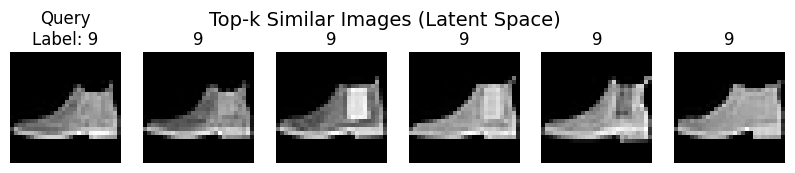

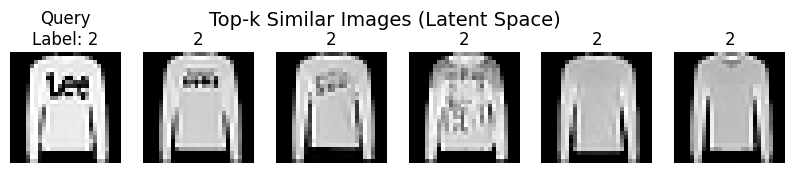

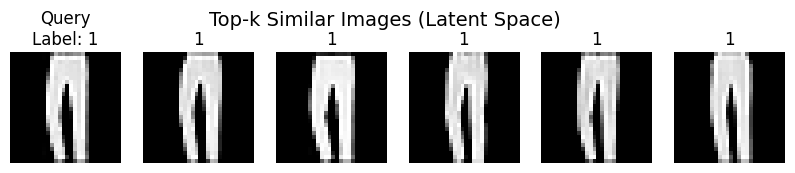

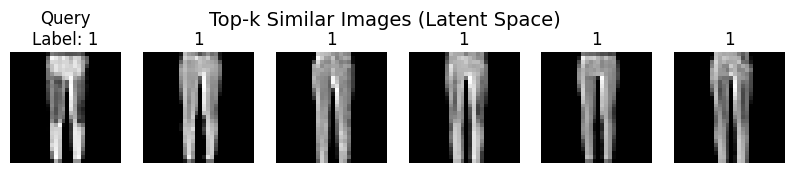

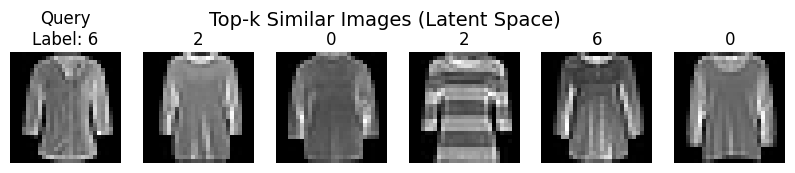

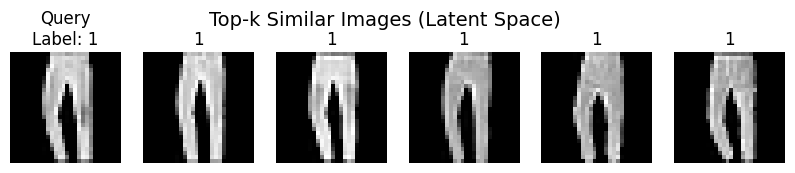

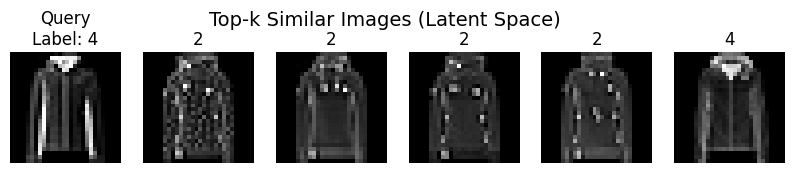

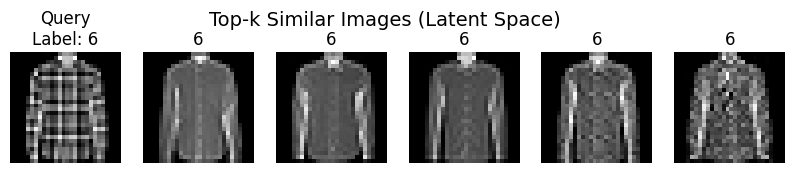

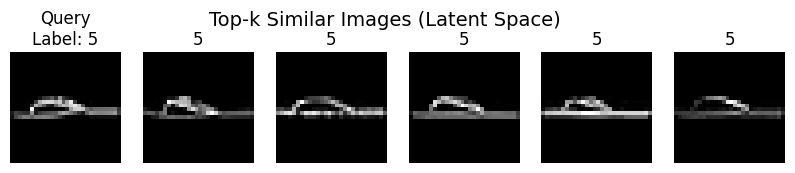

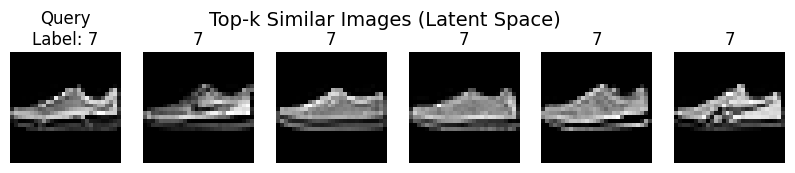

In [ ]:
for i in range(10):
    show_similar_images(index=i, topk=5)